In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import xarray as xr
from glob import glob
import os
from netCDF4 import Dataset
import pandas as pd
from datetime import datetime, date, timedelta
from pathlib import Path
import scipy
import scipy.ndimage
from mpl_toolkits.axes_grid1 import ImageGrid
import math

/usr/lib64/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [2]:
#variables
selected_time = 335000
negative_w_threshold = -0.25

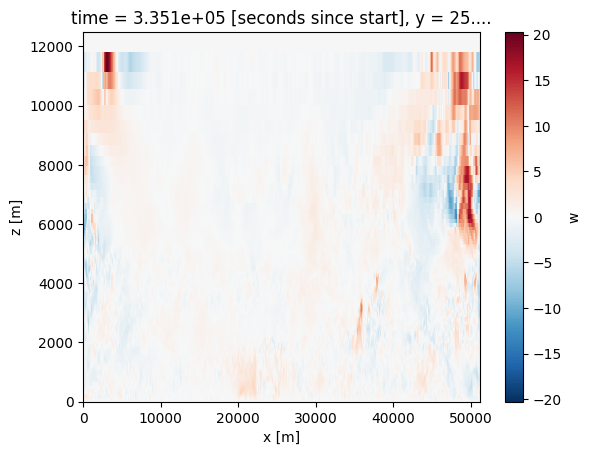

In [3]:
#Open datasets
ds_ql = xr.open_dataset("/mnt/stor-pool-01/projects/heus/BNF/Shallow_to_Deep/2025-06-19_nc/ql.xz.nc", decode_times=False).isel(y=0,time=slice(1,None))
ds_w = xr.open_dataset("/mnt/stor-pool-01/projects/heus/BNF/Shallow_to_Deep/2025-06-19_nc/w.xz.nc", decode_times=False).isel(y=0,time=slice(1,None)).rename({'zh':'z'}).interp(z=ds_ql.z)

#cleaning data
ds_ql = ds_ql.fillna(0)
ds_w = ds_w.fillna(0)

ds_w.w.sel(time=selected_time, method="nearest").plot(x="x")


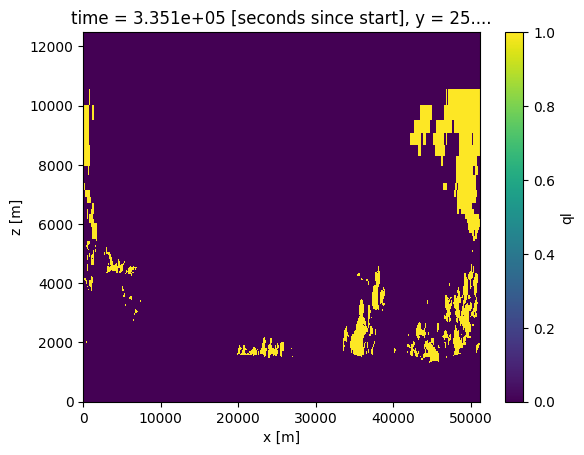

In [4]:
#creating binary mask for ql
ds_ql_binary = ds_ql.where(ds_ql.ql == 0, 1)

#plot
ds_ql_binary.ql.sel(time=selected_time, method="nearest").plot(x="x")


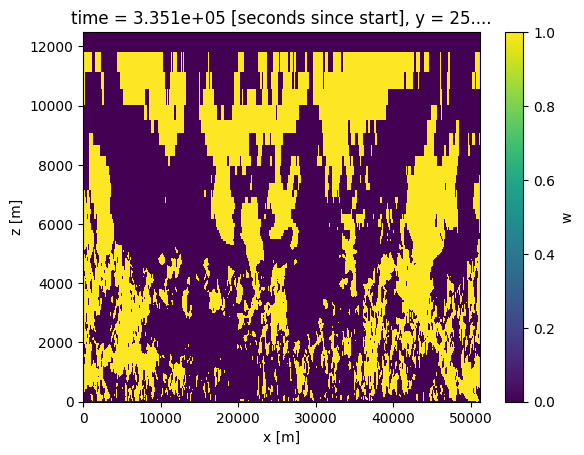

In [5]:
#creating binary mask for w
ds_w_binary = ds_w.where(ds_w.w < negative_w_threshold, 0).where(ds_w.w >= negative_w_threshold, 1)

#plot
ds_w_binary.w.sel(time=selected_time, method="nearest").plot(x="x")


In [6]:
ds_ql_binary_renamed = ds_ql_binary.rename_vars(ql="w") #renaming ql so it can be used

In [7]:
#unoptimized version

#shifting in all directions by shift_amount (keep at small numbers as higher numbers will not create a proper outline)
#also removing areas that w is not negative for



#ds_ql_shift_whole = ds_ql_binary_renamed.copy()
#ds_ql_shift_whole_past = 0 * ds_ql_binary_renamed.copy() #used to make sure loop exits when no significant changes were made in the current iteration
#while(not ds_ql_shift_whole.equals(ds_ql_shift_whole_past)):
#for i in range(shift_amount):
    #ds_ql_shift_whole_past = ds_ql_shift_whole.copy()
    #ds_ql_up = ds_ql_shift_whole.shift(z=1,fill_value=0)
    #ds_ql_down = ds_ql_shift_whole.shift(z=-1,fill_value=0)
    #ds_ql_right = ds_ql_shift_whole.roll(x=1)
    #ds_ql_left = ds_ql_shift_whole.roll(x=-1)

    #combining all the shifts
    #ds_ql_fullShift = ds_ql_up + ds_ql_right + ds_ql_left + ds_ql_down

    #masking w onto new area
    #ds_ql_fullShift *= ds_w_binary

    #adding shape to original image
    #ds_ql_shift_whole += ds_ql_fullShift
    #normalizing
    #ds_ql_shift_whole = ds_ql_shift_whole.where(ds_ql_shift_whole.w <= 0, 1)

    #if ds_ql_shift_whole.equals(ds_ql_shift_whole_past):
        #break
    #ds_ql_shift_whole_past = ds_ql_shift_whole.copy()


#subtracting original ql binary area
#ds_ql_shift_whole -= ds_ql_binary_renamed

#removing negative areas from previous subtraction
#ds_ql_shift_whole = ds_ql_shift_whole.where(ds_ql_shift_whole.w > 0, 0)

#plot
#ds_ql_shift_whole.w.sel(time=selected_time, method="nearest").plot(x="x")

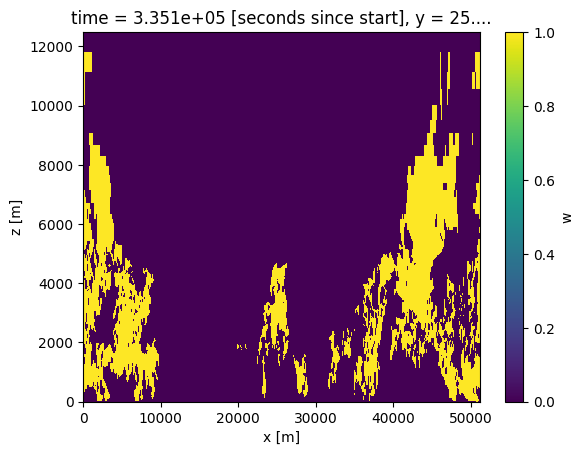

In [8]:
ql_mask = ds_ql_binary_renamed.w.values.astype(bool)
w_mask = ds_w_binary.w.values.astype(bool)

outline_mask = np.zeros_like(ql_mask)



for t in range(ql_mask.shape[0]):
    current = ql_mask[t, :, :]
    w_slice = w_mask[t, :, :]

    expansion = np.array([[0,1,0], [1,1,1], [0,1,0]])
    #expansion_3d = expansion[np.newaxis, :, :]

    while True:
        dilated_mask = scipy.ndimage.binary_dilation(current,structure=expansion)
        filtered_mask = dilated_mask & w_slice
        if np.array_equal(filtered_mask,current):
            break;
        current = filtered_mask.copy()

    outline_mask[t, :, :] = current & ~ql_mask[t, :, :]

ds_ql_shift_whole = ds_ql_binary_renamed.copy()
ds_ql_shift_whole["w"] = (ds_ql_binary_renamed["w"].dims, outline_mask.astype(float))

ds_ql_shift_whole.w.sel(time=selected_time, method="nearest").plot(x="x")

In [9]:
#NO LONGER NEEDED - code to convert z to zh

#ds_ql_fs_renamed = ds_ql_fs_renamed.rename(z="zh")

#interpolating z
#ds_ql_fs_zAdjust = ds_ql_fs_renamed.interp_like(ds_w)
#ds_ql_fs_zAdjust = ds_ql_fs_zAdjust.where(ds_ql_fs_zAdjust.w == 0, 1) #correcting values by normalizing them

#\/ \/ code to adjust w instead \/ \/
#ds_w_binary_noZh = ds_w_binary.rename(zh="z")
#ds_w_binary_zAdjust = ds_w_binary_noZh.interp_like(ds_ql)
#ds_w_binary_zAdjust = ds_w_binary_zAdjust.where(ds_w_binary_zAdjust.w == 0, 1)

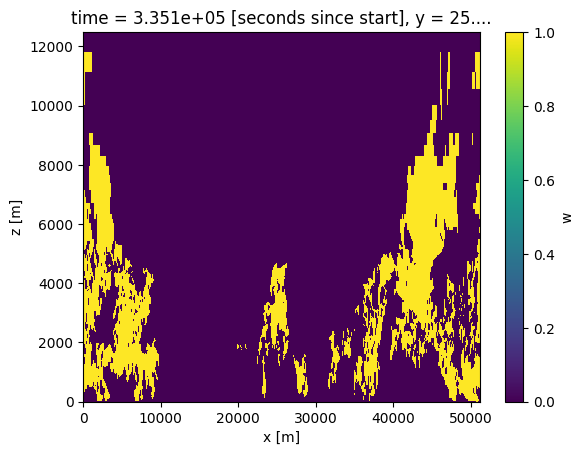

In [13]:



#combining the two masks
ds_shell_mask = ds_ql_shift_whole * ds_w_binary

#plot
ds_shell_mask.w.sel(time=selected_time, method="nearest").plot(x="x")

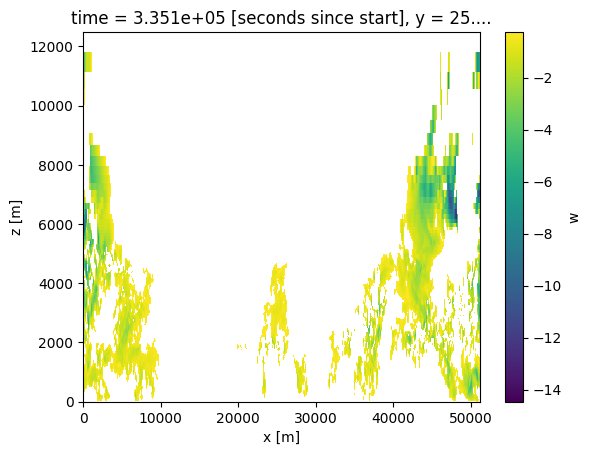

In [14]:
#shell w can now be obtained by multiplying the graph and the mask
ds_shell_mask = ds_shell_mask.w.where(ds_shell_mask.w != 0,np.nan)
ds_w_shell = ds_w * ds_shell_mask

#plot
ds_w_shell.w.sel(time=selected_time, method="nearest").plot(x="x")

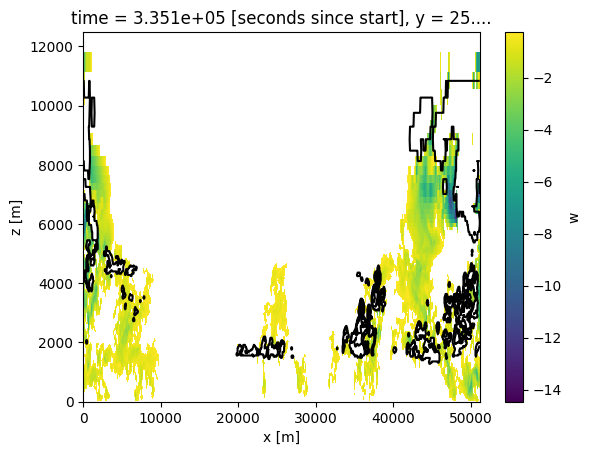

In [16]:
#adding contours of ql
ds_w_shell_contour = xr.merge([ds_w_shell,ds_ql])


#plotting
fig, ax = plt.subplots()
ds_w_shell_contour.ql.sel(time=selected_time, method="nearest").plot.contour(x="x",ax=ax,colors="black")
ds_w_shell_contour.w.sel(time=selected_time, method="nearest").plot(x="x",ax=ax)